In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [51]:
df = pd.read_csv('/content/flights.csv')
df

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,336771,2013,9,30,NaN,1455,NaN,NaN,1634,NaN,...,3393,NaN,JFK,DCA,NaN,213,14,55,2013-09-30 14:00:00,Endeavor Air Inc.
336772,336772,2013,9,30,NaN,2200,NaN,NaN,2312,NaN,...,3525,NaN,LGA,SYR,NaN,198,22,0,2013-09-30 22:00:00,Endeavor Air Inc.
336773,336773,2013,9,30,NaN,1210,NaN,NaN,1330,NaN,...,3461,N535MQ,LGA,BNA,NaN,764,12,10,2013-09-30 12:00:00,Envoy Air
336774,336774,2013,9,30,NaN,1159,NaN,NaN,1344,NaN,...,3572,N511MQ,LGA,CLE,NaN,419,11,59,2013-09-30 11:00:00,Envoy Air


In [55]:
X = df[['year', 'arr_time', 'dep_time']]
X

,year,arr_time,dep_time
0,2013,830.0,517.0
1,2013,850.0,533.0
2,2013,923.0,542.0
3,2013,1004.0,544.0
4,2013,812.0,554.0
...,...,...,...
336771,2013,NaN,NaN
336772,2013,NaN,NaN
336773,2013,NaN,NaN
336774,2013,NaN,NaN


In [54]:
df1 = df.iloc[:,[1,4,7]]
df1


,year,dep_time,arr_time
0,2013,517.0,830.0
1,2013,533.0,850.0
2,2013,542.0,923.0
3,2013,544.0,1004.0
4,2013,554.0,812.0
...,...,...,...
336771,2013,NaN,NaN
336772,2013,NaN,NaN
336773,2013,NaN,NaN
336774,2013,NaN,NaN


# Train Test Split

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df1.drop('arr_time', axis = 1),
                                                    df1['arr_time'],
                                                    test_size = 0.3,
                                                    random_state = 0)

X_train.shape, X_test.shape

((235743, 2), (101033, 2))

In [60]:
X_train

,year,dep_time
307329,2013,1807.0
95557,2013,903.0
167741,2013,1714.0
260166,2013,1506.0
65745,2013,1809.0
...,...,...
122579,2013,554.0
304137,2013,1348.0
152315,2013,1025.0
117952,2013,NaN


In [61]:
X_test

,year,dep_time
208878,2013,1426.0
100438,2013,1618.0
188557,2013,1813.0
153630,2013,1739.0
221554,2013,1057.0
...,...,...
248533,2013,2147.0
327884,2013,944.0
70059,2013,858.0
111692,2013,1251.0


In [62]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

#transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
X_train_scaled

array([[ 0.        ,  0.93681473],
       [ 0.        , -0.91423507],
       [ 0.        ,  0.74638594],
       ...,
       [ 0.        , -0.66442525],
       [ 0.        ,         nan],
       [ 0.        , -1.32171174]])

In [65]:
X_test_scaled

array([[ 0.        ,  0.15667096],
       [ 0.        ,  0.54981428],
       [ 0.        ,  0.94910046],
       ...,
       [ 0.        , -1.00637804],
       [ 0.        , -0.2016628 ],
       [ 0.        ,  0.76276691]])

In [66]:
scaler.mean_

array([2013.        , 1349.48636779])

In [69]:
#converting scaled values to DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [70]:
X_train_scaled

,year,dep_time
0,0.0,0.936815
1,0.0,-0.914235
2,0.0,0.746386
3,0.0,0.320481
4,0.0,0.940910
...,...,...
235738,0.0,-1.628855
235739,0.0,-0.003044
235740,0.0,-0.664425
235741,0.0,NaN


In [71]:
X_test

,year,dep_time
208878,2013,1426.0
100438,2013,1618.0
188557,2013,1813.0
153630,2013,1739.0
221554,2013,1057.0
...,...,...
248533,2013,2147.0
327884,2013,944.0
70059,2013,858.0
111692,2013,1251.0


In [72]:
np.round(X_train.describe(), 1)

,year,dep_time
count,235743.0,229970.0
mean,2013.0,1349.5
std,0.0,488.4
min,2013.0,1.0
25%,2013.0,907.0
50%,2013.0,1402.0
75%,2013.0,1744.0
max,2013.0,2400.0


In [73]:
np.round(X_train_scaled.describe(), 1)

,year,dep_time
count,235743.0,229970.0
mean,0.0,0.0
std,0.0,1.0
min,0.0,-2.8
25%,0.0,-0.9
50%,0.0,0.1
75%,0.0,0.8
max,0.0,2.2


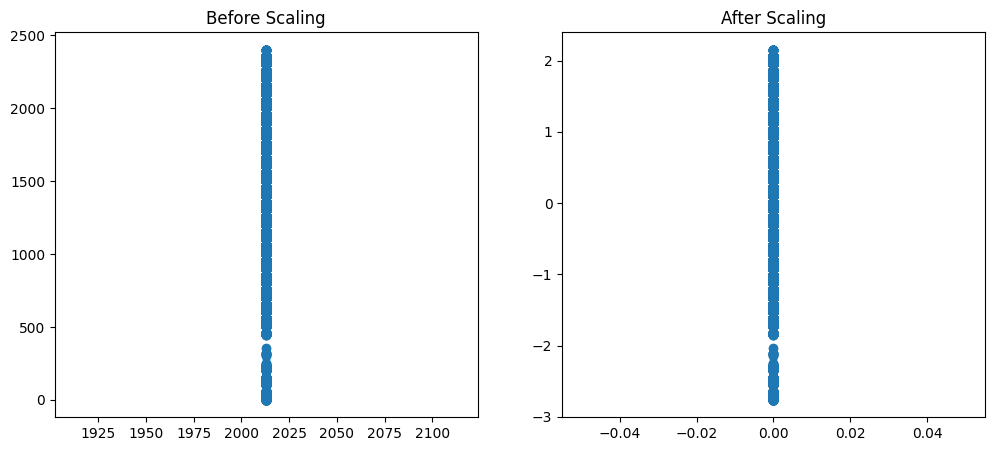

In [81]:
# Effect of Scaling

fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.set_title('Before Scaling')
ax1.scatter(X_train['year'], X_train['dep_time'])

ax2.set_title('After Scaling')
ax2.scatter(X_train_scaled['year'], X_train_scaled['dep_time'])

plt.show()

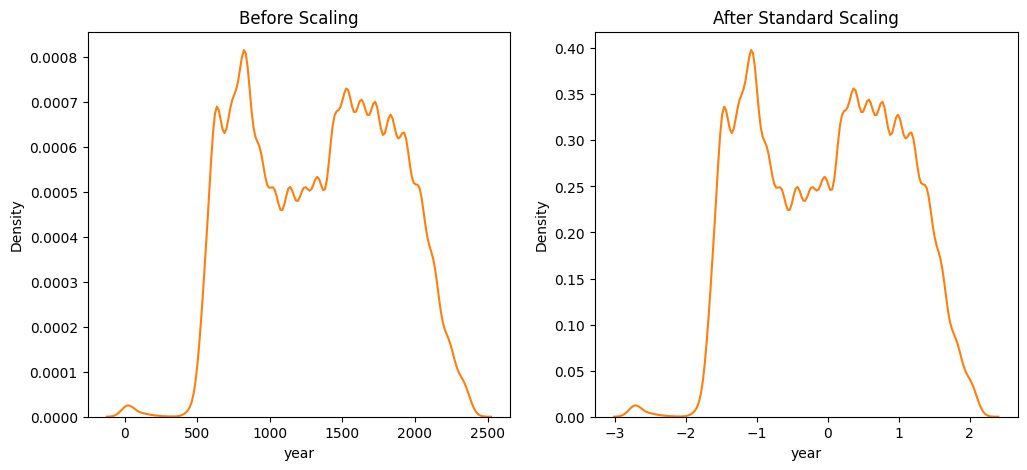

In [84]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['year'], ax = ax1)
sns.kdeplot(X_train['dep_time'], ax = ax1)

ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['year'], ax = ax2)
sns.kdeplot(X_train_scaled['dep_time'], ax =ax2)

plt.show()